In [116]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/revenue_ledger.csv')

In [118]:
# Read the content in the dataset
# Display first 5 rows
df.head()

,Account,Cust Code,Part Code,Inv Date,Quantity,Price,Tax,Others
0,Account A,Cust-00762,Part-01473,2022-04-01,3.0,"9,787.10","8,415.52",694.14
1,Account A,Cust-00762,Part-01473,2022-04-01,10.0,"9,787.10","28,051.74","2,313.80"
2,Account A,Cust-00519,Part-01675,2022-04-01,18.6,"46,045.00","1,54,158.66","10,105.96"
3,Account A,Cust-00302,Part-01312,2022-04-01,5.0,"4,761.14","4,570.44","1,585.65"
4,Account A,Cust-00302,Part-01573,2022-04-01,5.0,"4,752.34","4,562.52","1,585.65"


In [119]:
# Display shape of the dataset
df.shape

(234516, 8)

In [120]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234516 entries, 0 to 234515
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Account    234516 non-null  object 
 1   Cust Code  234516 non-null  object 
 2   Part Code  234516 non-null  object 
 3   Inv Date   234516 non-null  object 
 4   Quantity   234516 non-null  float64
 5   Price      234516 non-null  object 
 6   Tax        209310 non-null  object 
 7   Others     221748 non-null  object 
dtypes: float64(1), object(7)
memory usage: 14.3+ MB


In [121]:
# Convert date column
df['Inv Date'] = pd.to_datetime(df['Inv Date'])

In [122]:
# Convert numeric columns
numeric_columns = ['Quantity','Price','Tax','Others']

for col in numeric_columns:

  # clean numeric columns
  df[col] = (df[col].astype(str).str.replace(',','',regex=False).str.strip())

  # Convert to numeric
  df[col] = pd.to_numeric(df[col],errors='coerce')

In [123]:
# Check for missing values
df.isnull().sum()

,0
Account,0
Cust Code,0
Part Code,0
Inv Date,0
Quantity,0
Price,0
Tax,25206
Others,12768


Tax and others columns contain missing values.

Based on business interpretation, missing values in these columns likely indicate:
- no tax applied
- no extra charges incurred

Therefore, missing values were imputed with 0 instead of statistical measures like mean and median.

In [124]:
# Fill missing values
df.fillna(0,inplace=True)

In [125]:
# check for duplicate records
df.duplicated().sum()

np.int64(34278)

In [126]:
duplicated_rows = df[df.duplicated()]
duplicated_rows.head(10)

,Account,Cust Code,Part Code,Inv Date,Quantity,Price,Tax,Others
17,Account A,Cust-00274,Part-01646,2022-04-01,10.0,4278.60,8026.20,1804.00
18,Account A,Cust-00274,Part-01645,2022-04-01,10.0,4259.10,7991.10,1804.00
23,Account A,Cust-00274,Part-01646,2022-04-01,10.0,4278.60,8026.20,1804.00
24,Account A,Cust-00274,Part-01645,2022-04-01,10.0,4259.10,7991.10,1804.00
33,Account A,Cust-00274,Part-01626,2022-04-01,5.0,4384.20,4044.78,550.00
34,Account A,Cust-00274,Part-01625,2022-04-01,5.0,4378.30,4039.47,550.00
45,Account A,Cust-00274,Part-01584,2022-04-02,5.0,2513.92,2262.53,0.00
47,Account A,Cust-00274,Part-01605,2022-04-02,5.0,3106.04,2819.47,133.50
64,Account A,Cust-00274,Part-01632,2022-04-02,24.0,833.50,3702.80,567.12
65,Account A,Cust-00274,Part-01632,2022-04-02,24.0,833.50,3702.80,567.12


In [127]:
df_clean = df.drop_duplicates()

In [128]:
df['Revenue'] = (df['Quantity'] * df['Price']) + df['Tax'] + df['Others']

In [129]:
df_clean['Revenue'] = (df_clean['Quantity'] * df_clean['Price']) + df_clean['Tax'] + df_clean['Others']

/tmp/ipykernel_10559/1305129700.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Revenue'] = (df_clean['Quantity'] * df_clean['Price']) + df_clean['Tax'] + df_clean['Others']


In [130]:
df['Revenue'].mean()

np.float64(70146.41518996954)

In [131]:
df_clean['Revenue'].mean()

np.float64(74527.3868378185)

In [132]:
bf = df['Revenue'].sum()
bf

np.float64(16450456704.690899)

In [133]:
af = df_clean['Revenue'].sum()
af

np.float64(14923214885.6311)

In [134]:
bf-af

np.float64(1527241819.0597992)

A large number of duplicate rows(34278) were identified.

However, removing them caused a significant revenue reduction (~1.53B) indicating that these records likely represent genuine repeated transactions rather than accidental duplicates.

since the dataset does not contain unique invoice identifier, duplicates were retained to avoid underestimating actual revenue.

In [135]:
# Check for Outliers
outliers_columns = ['Quantity','Price','Tax','Others','Revenue']

for col in outliers_columns:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)

  IQR = q3-q1

  LB = q1 - 1.5*IQR
  UB = q3 + 1.5*IQR

  Outliers = df[(df[col] < LB) | (df[col] > UB)]

  print(f'{col} Outliers:',Outliers.shape[0])

Quantity Outliers: 28587
Price Outliers: 7074
Tax Outliers: 14263
Others Outliers: 12783
Revenue Outliers: 19374


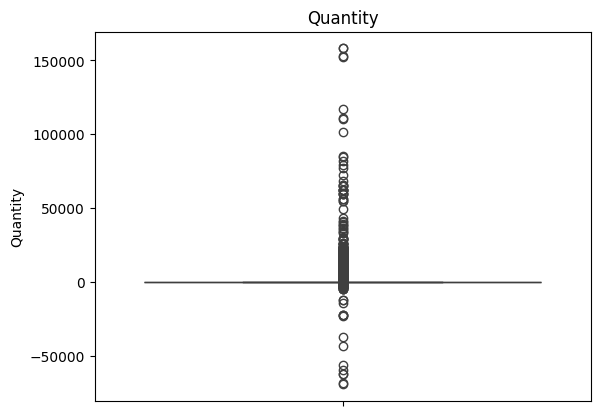

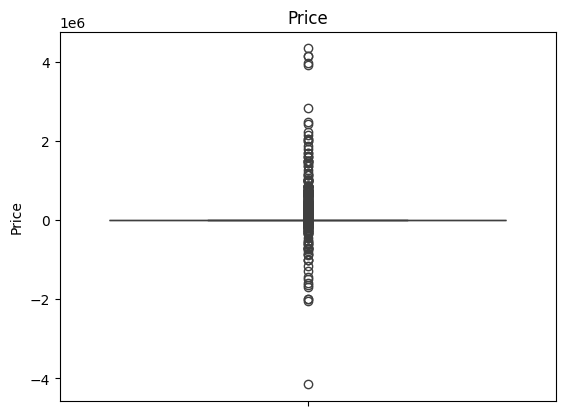

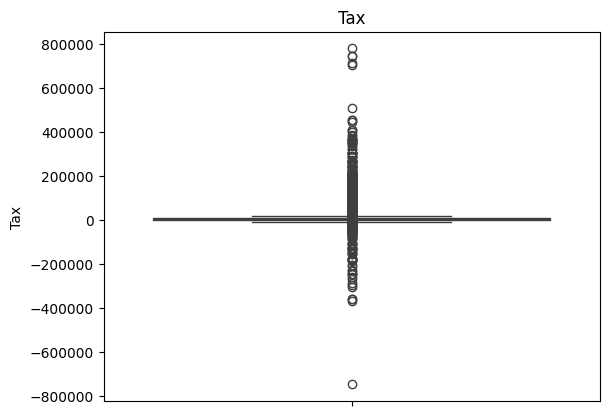

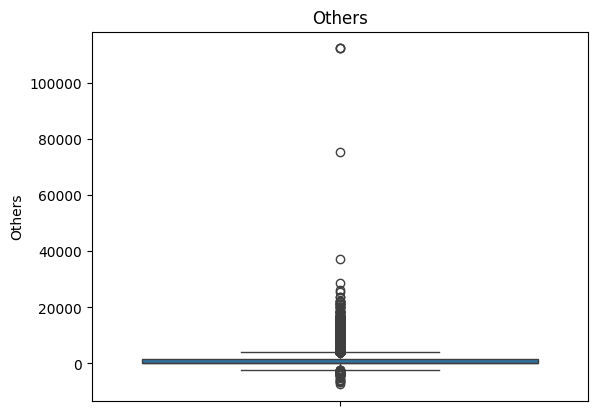

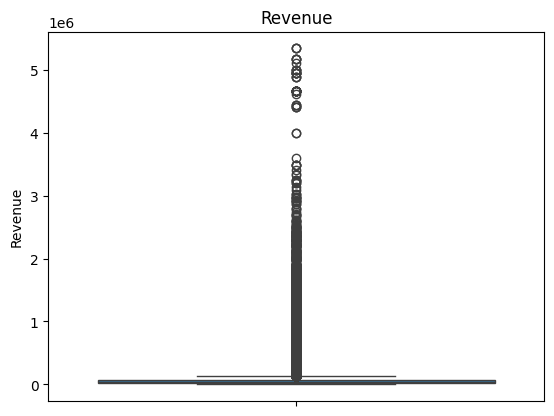

In [136]:
for col in outliers_columns:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

Outliers analysis was performed across Quantity,Price, Tax, Others and Revenue Columns using IQR method.

A significant amount of outliers were identified, particularly in revenue and Quantity columns. These can be due to business scenarios such as:
- bulk purchase
- invoice reversals
- cancellations
- pricing variations
- operational adjustments

Therefore, outliers were retained to preserve behavior and forecasting accuracy.

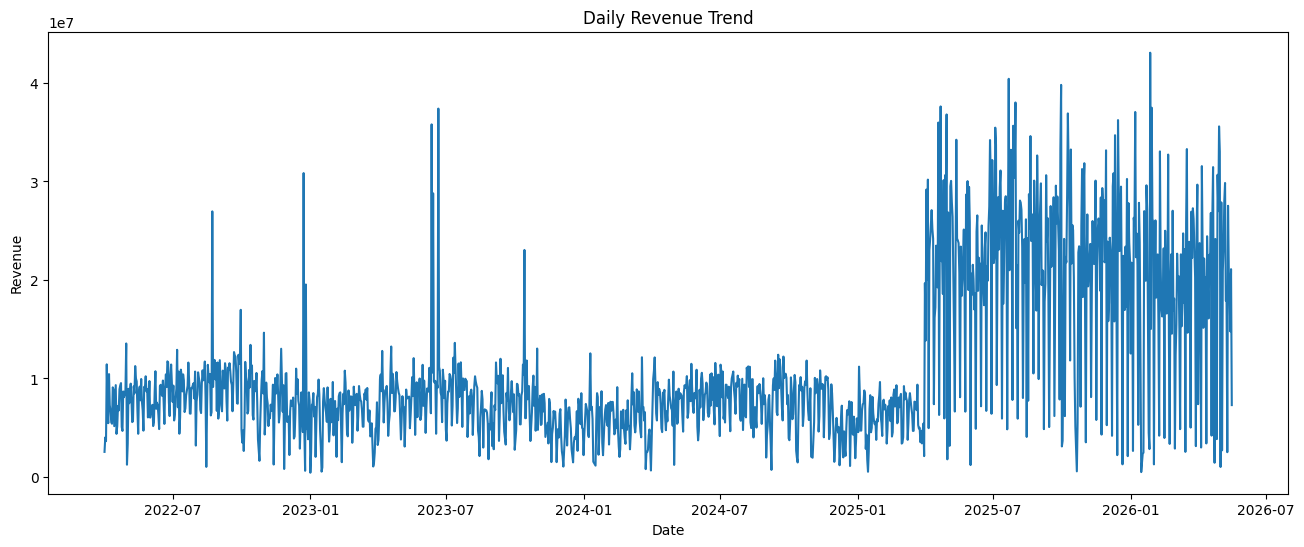

In [137]:
# Daily revenue trend
daily_revenue = df.groupby('Inv Date')['Revenue'].sum().reset_index()

plt.figure(figsize=(16,6))
plt.plot(daily_revenue['Inv Date'],daily_revenue['Revenue'])
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

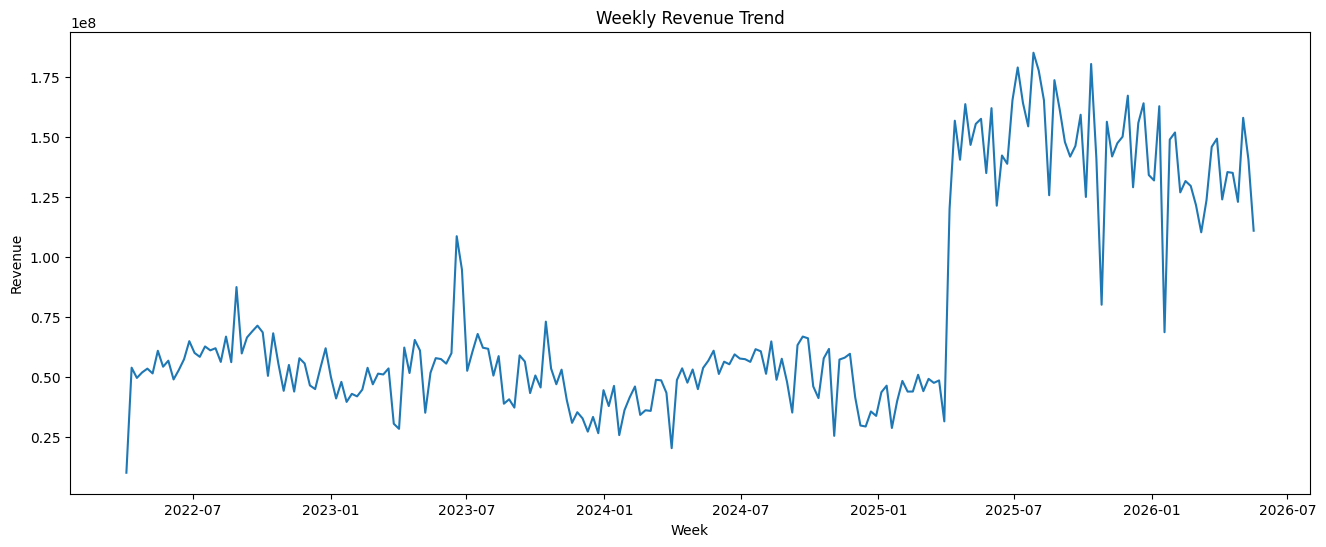

In [138]:
# Weekly Revenue Trend

weekly_trend = df.groupby(pd.Grouper(key = 'Inv Date',freq = 'W'))['Revenue'].sum().reset_index()

plt.figure(figsize=(16,6))
plt.plot(weekly_trend['Inv Date'],weekly_trend['Revenue'])
plt.title('Weekly Revenue Trend')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.show()

/tmp/ipykernel_10559/314023296.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = df.groupby(pd.Grouper(key = 'Inv Date',freq = 'M'))['Revenue'].sum().reset_index()


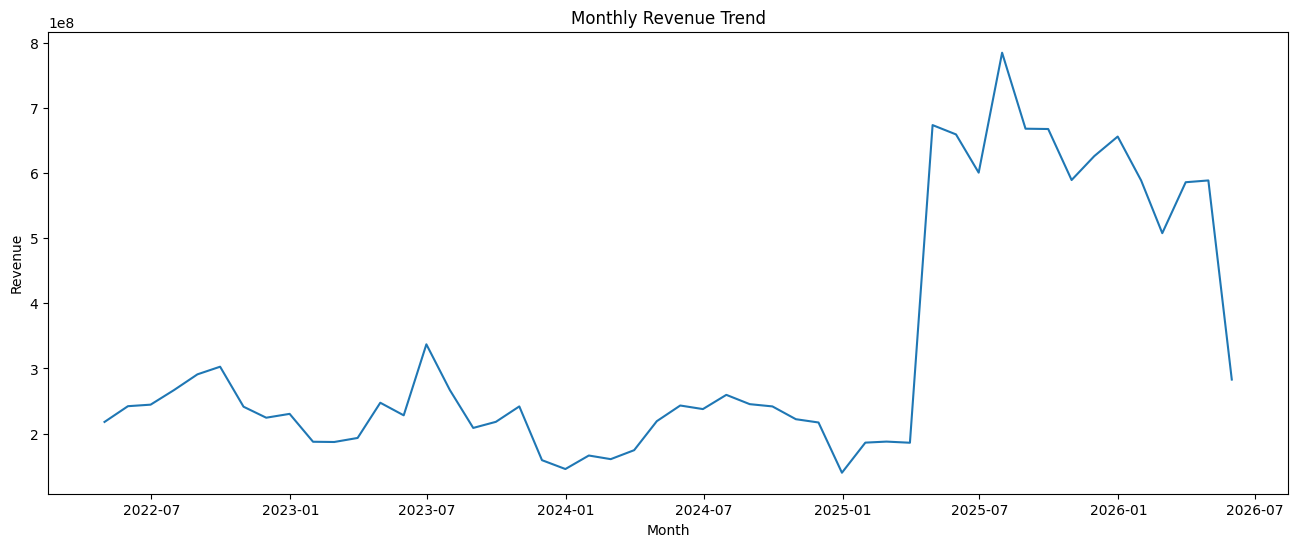

In [139]:
# Monthly Revenue Trend

monthly_trend = df.groupby(pd.Grouper(key = 'Inv Date',freq = 'M'))['Revenue'].sum().reset_index()

plt.figure(figsize=(16,6))
plt.plot(monthly_trend['Inv Date'],monthly_trend['Revenue'])
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

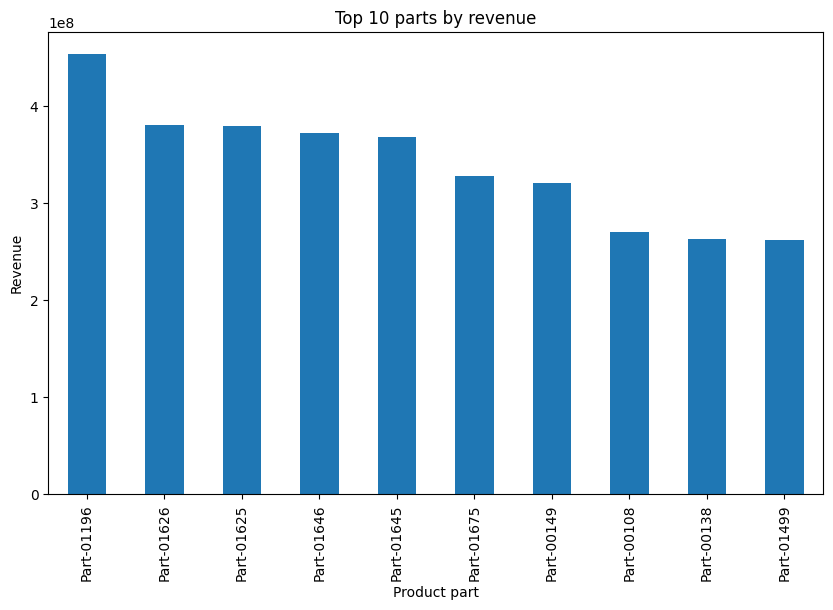

In [140]:
# Revenue by Product Parts

part_revenue = df.groupby('Part Code')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
part_revenue.plot(kind='bar')
plt.title('Top 10 parts by revenue')
plt.xlabel('Product part')
plt.ylabel('Revenue')
plt.show()

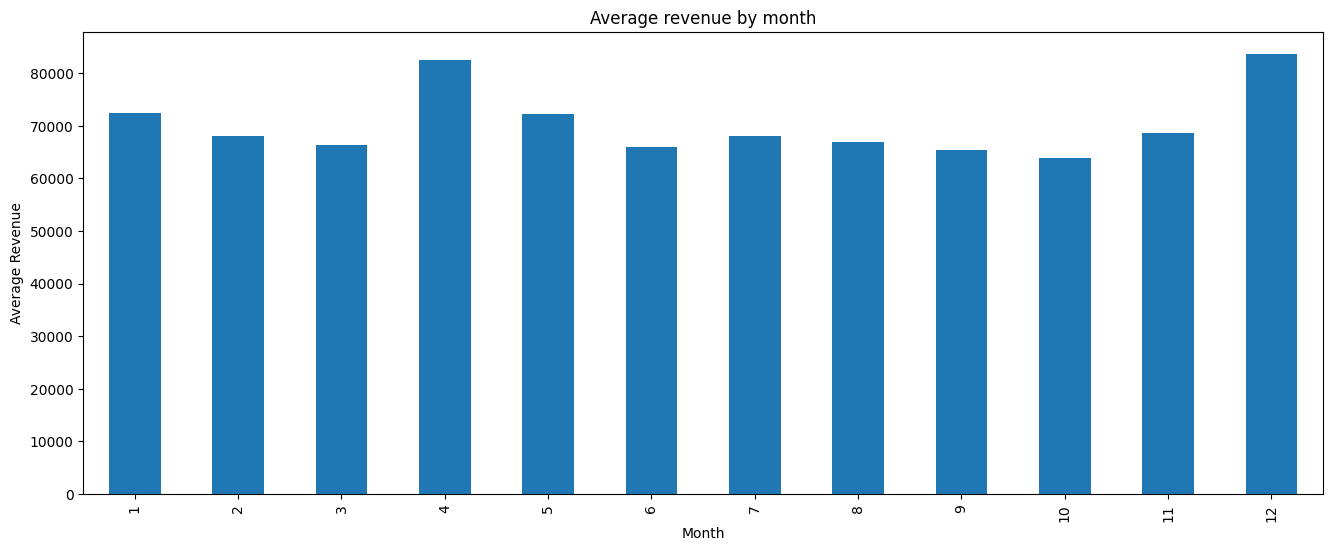

In [141]:
# Seasonality Patterns
# Monthly seasonality

df['Month'] = df['Inv Date'].dt.month

monthly_avg = df.groupby('Month')['Revenue'].mean()
plt.figure(figsize=(16,6))
monthly_avg.plot(kind = 'bar')
plt.title('Average revenue by month')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.show()


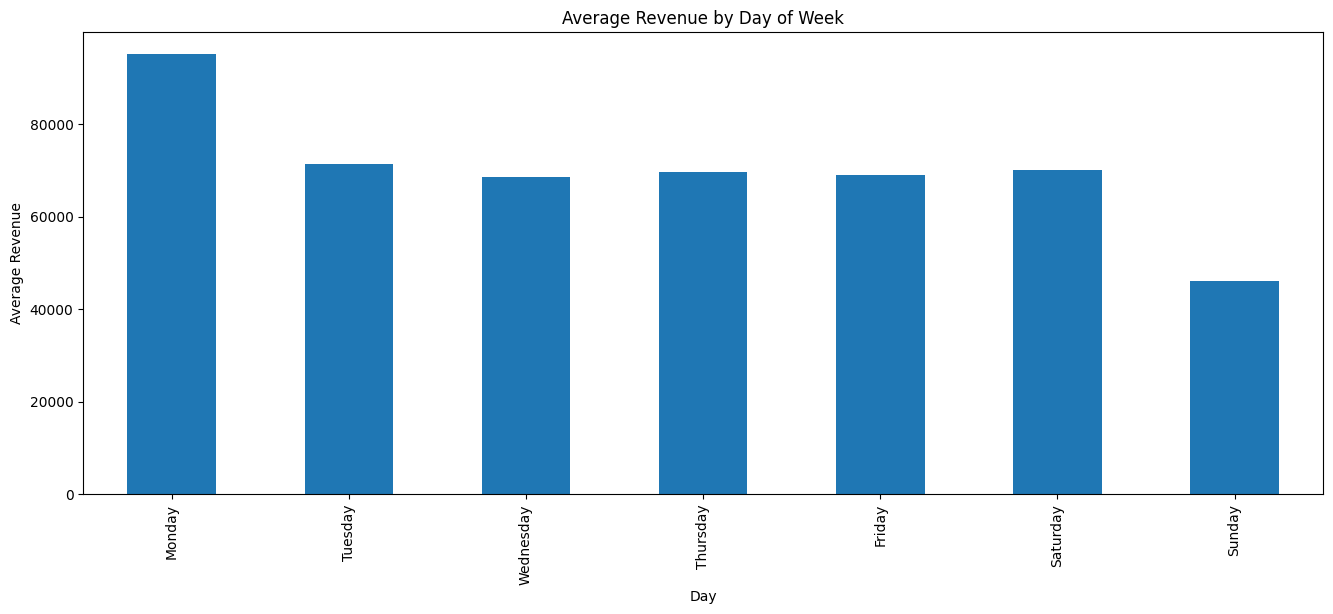

In [142]:
# Day-of-week Effects

df['Day_name'] = df['Inv Date'].dt.day_name()

daywise_revenue = df.groupby('Day_name')['Revenue'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(16,6))
daywise_revenue.plot(kind='bar')
plt.title('Average Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Revenue')
plt.show()

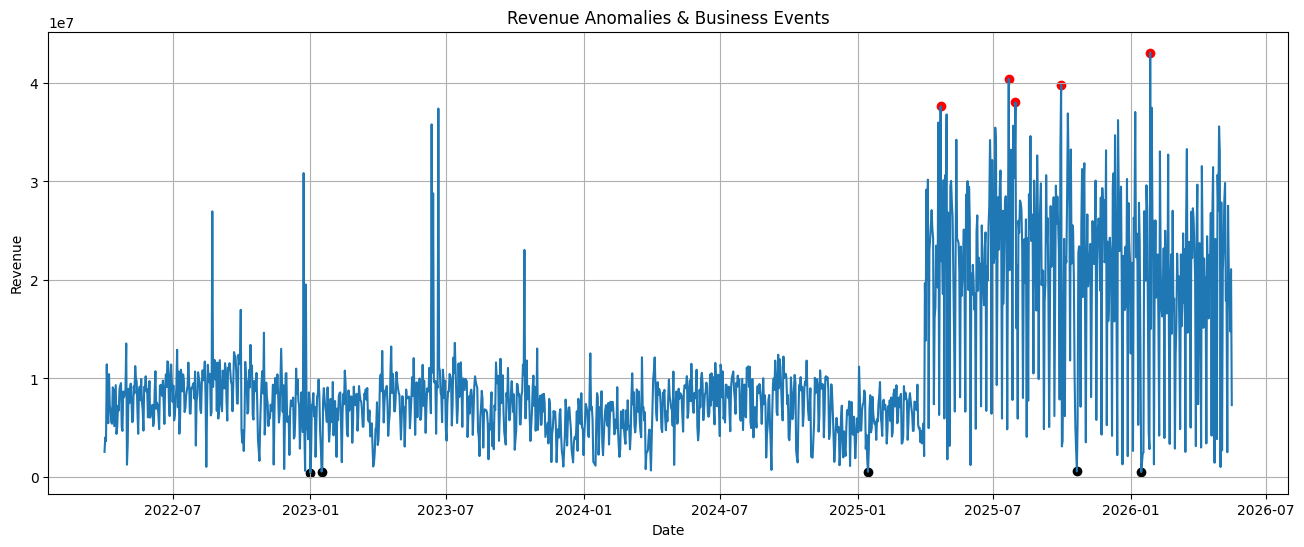

In [143]:
# Anomaly Detection / Business Events
# Daily Revenue with spikes and dips

plt.figure(figsize=(16,6))
plt.plot(daily_revenue['Inv Date'],daily_revenue['Revenue'])

# Top spikes

top_spikes = daily_revenue.nlargest(5,'Revenue')

plt.scatter(top_spikes['Inv Date'],top_spikes['Revenue'],color = 'Red',label = 'Revenue spikes')

# Top dips

top_dips = daily_revenue.nsmallest(5,'Revenue')

plt.scatter(top_dips['Inv Date'],top_dips['Revenue'],color = 'black',label = 'Revenue dips')

plt.title('Revenue Anomalies & Business Events')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid('True')
plt.show()

##Forecasting Model

###Prophet Model

In [144]:
# Prepare daily revenue data

daily_revenue = df.groupby('Inv Date')['Revenue'].sum().reset_index()

# rename columns for prophet

prophet_df = daily_revenue.rename(columns={'Inv Date':'ds','Revenue':'y'})
prophet_df = prophet_df.sort_values('ds')

prophet_df.head()

,ds,y
0,2022-04-01,2547015.55
1,2022-04-02,4016314.20
2,2022-04-03,3637565.83
3,2022-04-04,11432001.26
4,2022-04-05,7027125.59


In [145]:
# Train Prophet Model

from prophet import Prophet

train_size = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

model.fit(train)

future_test = model.make_future_dataframe(periods = len(test), freq = 'D')
forecast_test = model.predict(future_test)
forecast_test.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1486,2026-05-10,3.807324e+07,2.770240e+07,4.331150e+07,3.415218e+07,4.202126e+07,-2.426173e+06,-2.426173e+06,-2.426173e+06,-3.818634e+06,-3.818634e+06,-3.818634e+06,1.392460e+06,1.392460e+06,1.392460e+06,0.0,0.0,0.0,3.564707e+07
1487,2026-05-11,3.813141e+07,3.014080e+07,4.663908e+07,3.418325e+07,4.209685e+07,2.990749e+05,2.990749e+05,2.990749e+05,-1.131714e+06,-1.131714e+06,-1.131714e+06,1.430789e+06,1.430789e+06,1.430789e+06,0.0,0.0,0.0,3.843048e+07
1488,2026-05-12,3.818958e+07,3.226751e+07,4.878470e+07,3.421432e+07,4.217244e+07,2.541936e+06,2.541936e+06,2.541936e+06,1.063820e+06,1.063820e+06,1.063820e+06,1.478116e+06,1.478116e+06,1.478116e+06,0.0,0.0,0.0,4.073151e+07
1489,2026-05-13,3.824774e+07,3.276311e+07,4.902642e+07,3.425237e+07,4.224802e+07,2.587917e+06,2.587917e+06,2.587917e+06,1.055922e+06,1.055922e+06,1.055922e+06,1.531995e+06,1.531995e+06,1.531995e+06,0.0,0.0,0.0,4.083566e+07
1490,2026-05-14,3.830591e+07,3.293191e+07,4.894093e+07,3.429058e+07,4.232361e+07,2.442132e+06,2.442132e+06,2.442132e+06,8.522609e+05,8.522609e+05,8.522609e+05,1.589871e+06,1.589871e+06,1.589871e+06,0.0,0.0,0.0,4.074805e+07


In [146]:
# Extract only test forecast

test_forecast = forecast_test.tail(len(test))

actual = test['y'].values

predict = test_forecast['yhat'].values

# Evaluation metrics

from sklearn.metrics import root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

RMSE = np.round(root_mean_squared_error(actual,predict),2)
MAE = np.round(mean_absolute_error(actual,predict),2)
MAPE = np.round(mean_absolute_percentage_error(actual,predict),2)*100

print('RMSE:',RMSE)
print('MAE:',MAE)
print('MAPE:',MAPE)

Results = pd.DataFrame(index=[0],data={'Model':'Prophet','RMSE':RMSE,'Mean Absolute Error':MAE,'Mean Absolute Percentage Error':MAPE})
Results.set_index('Model',inplace=True)
Results

RMSE: 14087037.51
MAE: 10844657.17
MAPE: 204.99999999999997


,RMSE,Mean Absolute Error,Mean Absolute Percentage Error
Model,,,
Prophet,14087037.51,10844657.17,205.0


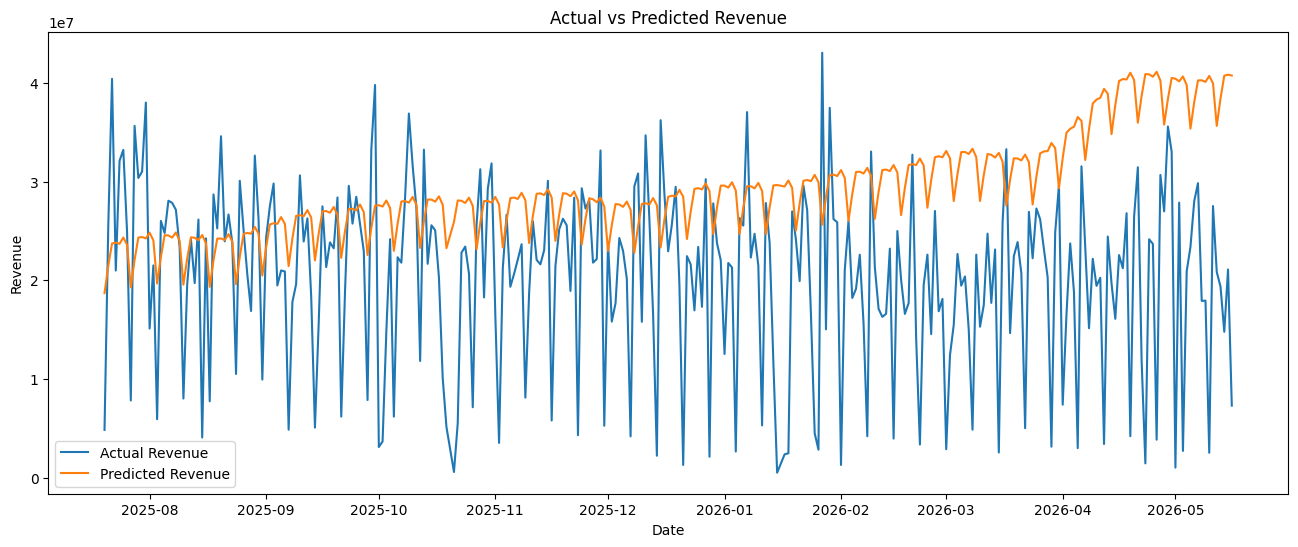

In [147]:
# Actual vs Predicted plots
plt.figure(figsize=(16,6))

plt.plot(test['ds'],actual,label = 'Actual Revenue')

plt.plot(test['ds'],predict,label = 'Predicted Revenue')

plt.title('Actual vs Predicted Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

## Feature Engineering

###Considered Daily Revenue

In [148]:
# Lag Features

daily_df = df.groupby('Inv Date')['Revenue'].sum().reset_index()

daily_df['lag_1'] = daily_df['Revenue'].shift(1)

daily_df['lag_7'] = daily_df['Revenue'].shift(7)

daily_df['lag_14'] = daily_df['Revenue'].shift(14)

daily_df['lag_21'] = daily_df['Revenue'].shift(21)

daily_df['lag_30'] = daily_df['Revenue'].shift(30)

In [149]:
# Rolling Mean & Roling Standard Deviation

daily_df['rolling_mean_7'] = daily_df['Revenue'].rolling(window=7).mean()

daily_df['rolling_std_7'] = daily_df['Revenue'].rolling(window=7).std()

daily_df['rolling_mean_14'] = daily_df['Revenue'].rolling(window=14).mean()

daily_df['rolling_std_14'] = daily_df['Revenue'].rolling(window=14).std()

daily_df['rolling_mean_30'] = daily_df['Revenue'].rolling(window=30).mean()

daily_df['rolling_std_30'] = daily_df['Revenue'].rolling(window=30).std()

In [150]:
# Calendar Features

daily_df['day_of_week'] = daily_df['Inv Date'].dt.day_of_week

daily_df['month'] = daily_df['Inv Date'].dt.month

daily_df['quarter'] = daily_df['Inv Date'].dt.quarter

daily_df['day_of_month'] = daily_df['Inv Date'].dt.day

daily_df['weeek_of_year'] = daily_df['Inv Date'].dt.isocalendar().week

daily_df['is_weekend'] = (daily_df['day_of_week'] >= 5).astype(int)

daily_df['is_month_end'] = (daily_df['Inv Date'].dt.is_month_end).astype(int)

daily_df['is_month_start'] = (daily_df['Inv Date'].dt.is_month_start).astype(int)

In [151]:
# Festival and Holiday Flags

!pip install holidays

import holidays
india_holidays = holidays.India()

daily_df['is_holiday'] = (daily_df['Inv Date'].isin(india_holidays)).astype(int)

festival_dates = [
    '2023-11-12',
    '2023-03-08',
    '2023-10-24',
    '2024-11-01',
    '2024-03-25',
    '2024-10-12',
    '2025-10-20',
    '2025-03-14'
]

festival_dates = pd.DataFrame(festival_dates)

daily_df['is_festival'] = (daily_df['Inv Date'].isin(festival_dates)).astype(int)

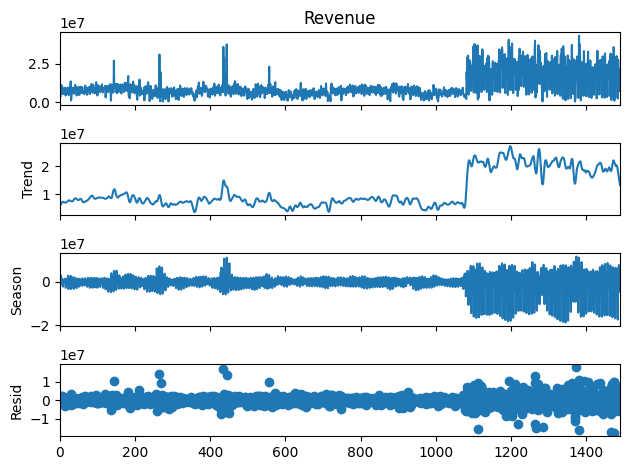

In [152]:
# Trend and Seasonality Decomposition

from statsmodels.tsa.seasonal import STL

stl = STL(daily_df['Revenue'],period=7)

result = stl.fit()

daily_df['Trend'] = result.trend
daily_df['Seasonal'] = result.seasonal
daily_df['Residual'] = result.resid

result.plot()
plt.show()

In [153]:
daily_df.dropna(inplace=True)

###Considering Weekly Revenue

In [154]:
weekly_df = df.groupby(pd.Grouper(key = 'Inv Date',freq = 'W'))['Revenue'].sum().reset_index()

weekly_df['lag_1'] = weekly_df['Revenue'].shift(1)

weekly_df['lag_7'] = weekly_df['Revenue'].shift(7)

weekly_df['lag_14'] = weekly_df['Revenue'].shift(14)

weekly_df['lag_21'] = weekly_df['Revenue'].shift(21)

weekly_df['lag_30'] = weekly_df['Revenue'].shift(30)

In [155]:
# Rolling Mean & Roling Standard Deviation

weekly_df['rolling_mean_7'] = weekly_df['Revenue'].rolling(window=7).mean()

weekly_df['rolling_std_7'] = weekly_df['Revenue'].rolling(window=7).std()

weekly_df['rolling_mean_14'] = weekly_df['Revenue'].rolling(window=14).mean()

weekly_df['rolling_std_14'] = weekly_df['Revenue'].rolling(window=14).std()

weekly_df['rolling_mean_30'] = weekly_df['Revenue'].rolling(window=30).mean()

weekly_df['rolling_std_30'] = weekly_df['Revenue'].rolling(window=30).std()

In [156]:
# Calendar Features

weekly_df['day_of_week'] = weekly_df['Inv Date'].dt.day_of_week

weekly_df['month'] = weekly_df['Inv Date'].dt.month

weekly_df['quarter'] = weekly_df['Inv Date'].dt.quarter

weekly_df['day_of_month'] = weekly_df['Inv Date'].dt.day

weekly_df['weeek_of_year'] = weekly_df['Inv Date'].dt.isocalendar().week

weekly_df['is_weekend'] = (weekly_df['day_of_week'] >= 5).astype(int)

weekly_df['is_month_end'] = (weekly_df['Inv Date'].dt.is_month_end).astype(int)

weekly_df['is_month_start'] = (weekly_df['Inv Date'].dt.is_month_start).astype(int)

In [157]:
# Festival and Holiday Flags

!pip install holidays

import holidays
india_holidays = holidays.India()

weekly_df['is_holiday'] = (weekly_df['Inv Date'].isin(india_holidays)).astype(int)

festival_dates = [
    '2023-11-12',
    '2023-03-08',
    '2023-10-24',
    '2024-11-01',
    '2024-03-25',
    '2024-10-12',
    '2025-10-20',
    '2025-03-14'
]

festival_dates = pd.DataFrame(festival_dates)

weekly_df['is_festival'] = (weekly_df['Inv Date'].isin(festival_dates)).astype(int)

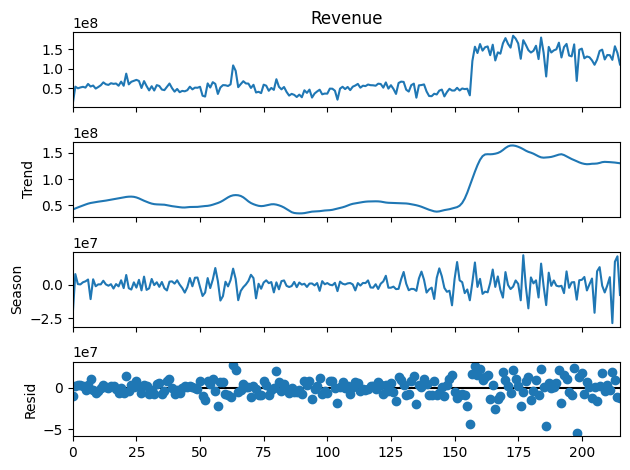

In [158]:
# Trend and Seasonality Decomposition

from statsmodels.tsa.seasonal import STL

stl = STL(weekly_df['Revenue'],period=7)

result = stl.fit()

weekly_df['Trend'] = result.trend
weekly_df['Seasonal'] = result.seasonal
weekly_df['Residual'] = result.resid

result.plot()
plt.show()

In [159]:
weekly_df.dropna(inplace=True)

In [160]:
# Product Mix over time

product_mix = df.groupby([pd.Grouper(key='Inv Date',freq='M'),'Part Code'])['Revenue'].sum().reset_index()

product_mix.head()

/tmp/ipykernel_10559/2382039554.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  product_mix = df.groupby([pd.Grouper(key='Inv Date',freq='M'),'Part Code'])['Revenue'].sum().reset_index()


,Inv Date,Part Code,Revenue
0,2022-04-30,Part-00416,6973.80
1,2022-04-30,Part-00419,63790.80
2,2022-04-30,Part-00453,32780.80
3,2022-04-30,Part-00472,133160.64
4,2022-04-30,Part-00475,265457.52


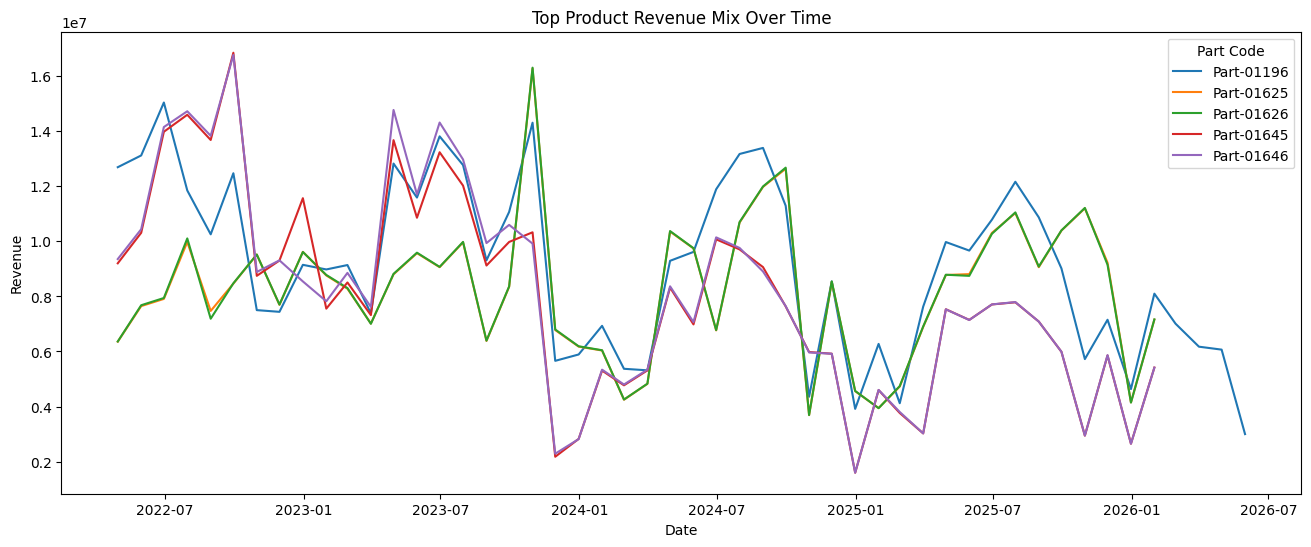

In [161]:
 # Top products over time

 top_parts = df.groupby('Part Code')['Revenue'].sum().sort_values(ascending=False).head(5).index

 top_product_mix = product_mix[product_mix['Part Code'].isin(top_parts)]

 plt.figure(figsize=(16,6))
 sns.lineplot(data=top_product_mix,x='Inv Date',y='Revenue',hue='Part Code')
 plt.title('Top Product Revenue Mix Over Time')
 plt.xlabel('Date')
 plt.ylabel('Revenue')
 plt.show()

In [162]:
if 'Channel' in df.columns:
  channel_mix = (df.groupby([pd.Grouper(key='Inv date',freq='M'),'Channel'])['Revenue'].sum().reset_index())

  plt.figure(figsize=(16,6))

  sns.lineplot(data=channel_mix,x='Inv date',y='Revenue',hue='Channel')
  plt.title('Channel Mix Over Time')
  plt.show()

In [163]:
daily_df.columns

Index(['Inv Date', 'Revenue', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_30',
       'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14',
       'rolling_mean_30', 'rolling_std_30', 'day_of_week', 'month', 'quarter',
       'day_of_month', 'weeek_of_year', 'is_weekend', 'is_month_end',
       'is_month_start', 'is_holiday', 'is_festival', 'Trend', 'Seasonal',
       'Residual'],
      dtype='object')

In [164]:
feature_cols = ['lag_1', 'lag_7', 'lag_30','lag_14','lag_21', 'rolling_mean_7',
       'rolling_std_7','rolling_mean_14','rolling_std_14', 'rolling_mean_30', 'rolling_std_30', 'day_of_week',
       'month', 'quarter', 'day_of_month', 'weeek_of_year', 'is_weekend',
       'is_month_end', 'is_month_start', 'is_holiday', 'is_festival', 'Trend',
       'Seasonal']

In [165]:
# XGBoost Model Development

!pip install XGBoost

from xgboost import XGBRegressor

####Daily Revenue Metrics

In [166]:
X = daily_df[feature_cols]
y = daily_df['Revenue']

train_size = int(len(daily_df) * 0.8)

X_train = X.iloc[:train_size]

X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]

y_test = y.iloc[train_size:]

In [167]:
xgb_model = XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=4,min_child_weight=3,subsample=0.9,colsample_bytree=0.9,gamma=0.1,random_state=42)

xgb_model.fit(X_train,y_train)

y_pred = xgb_model.predict(X_test)

In [168]:
RMSE = np.round(root_mean_squared_error(y_pred,y_test),2)
MAE = np.round(mean_absolute_error(y_pred,y_test),2)
MAPE = np.round(mean_absolute_percentage_error(y_pred,y_test),2)*100

print('RMSE:',RMSE)
print('MAE:',MAE)
print('MAPE:',MAPE)

Results1 = pd.DataFrame(index=[0],data={'Model':'XGBoost Daily Revenue','RMSE':RMSE,'Mean Absolute Error':MAE,'Mean Absolute Percentage Error':MAPE})
Results1.set_index('Model',inplace=True)
Results = pd.concat([Results,Results1])
Results

RMSE: 4810796.54
MAE: 3535181.69
MAPE: 20.0


,RMSE,Mean Absolute Error,Mean Absolute Percentage Error
Model,,,
Prophet,14087037.51,10844657.17,205.0
XGBoost Daily Revenue,4810796.54,3535181.69,20.0


####Weekly Revenue Metrics

In [169]:
X = weekly_df[feature_cols]
y = weekly_df['Revenue']

train_size = int(len(weekly_df) * 0.8)

X_train = X.iloc[:train_size]

X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]

y_test = y.iloc[train_size:]

In [170]:
xgb_model = XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=4,min_child_weight=3,subsample=0.9,colsample_bytree=0.9,gamma=0.1,random_state=42)

xgb_model.fit(X_train,y_train)

y_pred = xgb_model.predict(X_test)

In [171]:
RMSE = np.round(root_mean_squared_error(y_pred,y_test),2)
MAE = np.round(mean_absolute_error(y_pred,y_test),2)
MAPE = np.round(mean_absolute_percentage_error(y_pred,y_test),2)*100

print('RMSE:',RMSE)
print('MAE:',MAE)
print('MAPE:',MAPE)

Results1 = pd.DataFrame(index=[0],data={'Model':'XGBoost Weekly Revenue','RMSE':RMSE,'Mean Absolute Error':MAE,'Mean Absolute Percentage Error':MAPE})
Results1.set_index('Model',inplace=True)
Results = pd.concat([Results,Results1])
Results

RMSE: 19809240.71
MAE: 14709194.68
MAPE: 11.0


,RMSE,Mean Absolute Error,Mean Absolute Percentage Error
Model,,,
Prophet,14087037.51,10844657.17,205.0
XGBoost Daily Revenue,4810796.54,3535181.69,20.0
XGBoost Weekly Revenue,19809240.71,14709194.68,11.0


###30-day Forecast and Anomaly Detection

In [172]:
future_days = 30

future_predictions = []

last_data = weekly_df.copy()

In [173]:
for i in range(future_days):

    latest_row = last_data.iloc[-1:].copy()

    # Update lag features

    latest_row['lag_1'] = (last_data['Revenue'].iloc[-1])

    latest_row['lag_7'] = (last_data['Revenue'].iloc[-7])

    latest_row['lag_14'] = (last_data['Revenue'].iloc[-14])

    latest_row['lag_21'] = (last_data['Revenue'].iloc[-21])

    latest_row['lag_30'] = (last_data['Revenue'].iloc[-30])

    # Rolling statistics

    latest_row['rolling_mean_7'] = (last_data['Revenue'].tail(7).mean())

    latest_row['rolling_std_7'] = (last_data['Revenue'].tail(7).std())

    latest_row['rolling_mean_14'] = (last_data['Revenue'].tail(14).mean())

    latest_row['rolling_std_14'] = (last_data['Revenue'].tail(14).std())

    latest_row['rolling_mean_30'] = (last_data['Revenue'].tail(30).mean())

    latest_row['rolling_std_30'] = (last_data['Revenue'].tail(30).std())

    # Predict

    pred = xgb_model.predict(latest_row[feature_cols])[0]

    future_predictions.append(pred)

    # Create next row

    next_date = (latest_row['Inv Date'] + pd.Timedelta(days=1)).values[0]

    new_row = latest_row.copy()

    new_row['Inv date'] = next_date

    new_row['Revenue'] = pred

    last_data = pd.concat([last_data,new_row])

In [174]:
future_predictions = future_predictions[:30]

In [175]:
future_dates = pd.date_range(start=weekly_df['Inv Date'].max() + pd.Timedelta(days=1),periods=30)

future_forecast_xgb = pd.DataFrame({'Date': future_dates,'Forecasted_Revenue': future_predictions})

print(future_forecast_xgb.head())

        Date  Forecasted_Revenue
0 2026-05-18         109084128.0
1 2026-05-19         110365192.0
2 2026-05-20         110365192.0
3 2026-05-21         110531592.0
4 2026-05-22         109133768.0


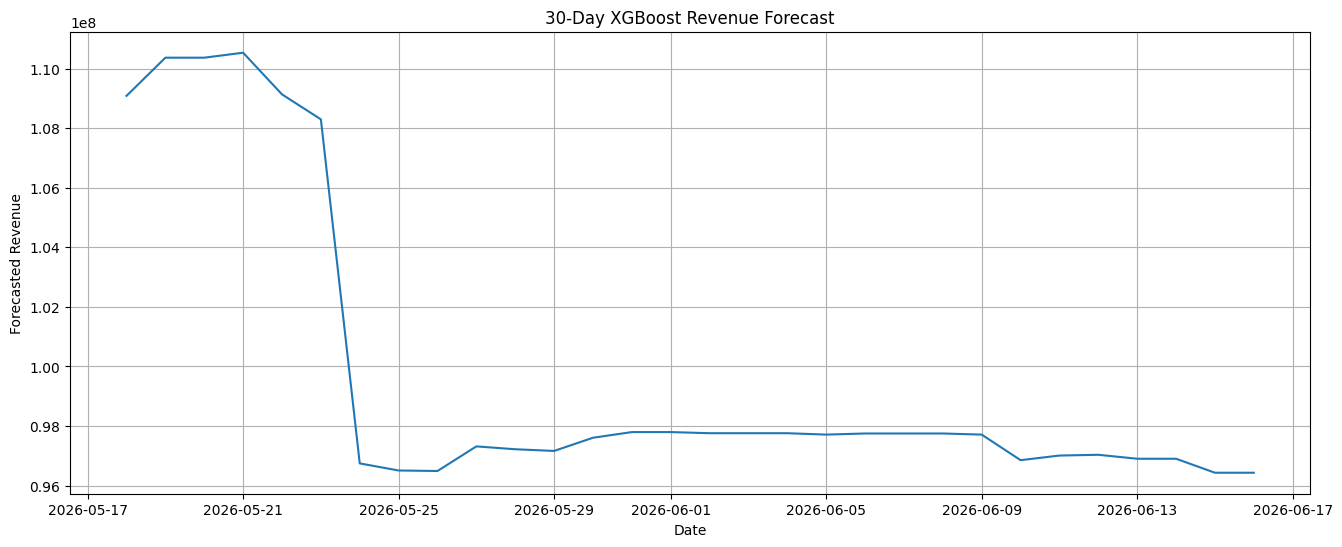

In [176]:
plt.figure(figsize=(16,6))

plt.plot(future_forecast_xgb['Date'],future_forecast_xgb['Forecasted_Revenue'])

plt.title('30-Day XGBoost Revenue Forecast')
plt.xlabel('Date')
plt.ylabel('Forecasted Revenue')
plt.grid(True)
plt.show()

##Task 4 - Business Interpretation

####Q1.  Based on the forecast, which weeks in the next 30 days have the highest revenue risk?

Based on the 30-day XGBoost forecast, the highest revenue risk appears during the second and fourth weeks of the forecast period.

The forecast shows a noticeable drop in revenue after the first week, followed by relatively stable but lower revenue levels during the remaining weeks.

In particular:
- Week 2 shows the sharpest decline in forecasted revenue
- Week 4 also shows slightly lower revenue compared to the middle weeks

These periods may indicate:
- lower customer demand
- reduced order activity
- possible operational slowdown

Therefore, the planning team should closely monitor inventory, production schedules, and demand patterns during these weeks to avoid overproduction or excess stock buildup.


####Q2.  If revenue underperforms by 15%, which product lines or regions are most exposed?

Product lines with
- highest revenue contribution
- highest historical volatality
- repeated negative transactions
would be most exposed to revenue decline.

Analysis showed that products such as : Part-01263, Part-01620 and other high revenue product groups has experienced recurring revenue reversals and fluctuations.

These products may face:
- demand instability
- cancellation risk
- pricing pressure
- operational inefficiencies

Since region-level information was not available in the dataset, geographic exposure could not be directly evaluated.


####Q3.  Would you recommend the planning team do differently based on this forecast?

Yes, Based on the forecast patterns and historical volatility, the planning team should consider
1. Dynamic inventory planning
2. Flexible production scheduling
3. Monitor hig-risk product lines
4. Improve forecast monitoring
5. Revenue risk management

####Q4. What additional data would significantly improve your model if you had access to it?

The forecasting model can be significantly improved by some additional operations and business data such as
- Operational data - stockout information, production schedules, procurement lead times
- Customer & Sales data - pending orders, cancellation reasons, customer demand patterns
- Pricing & Promotion Data -  discount campaigns, promotional periods, price changes
- Supply chain data - vendor delays, logistics disruptions, shipment timelines
- External factors - holidays and industrial shutdowns, macroeconomic indicators, raw material price fluctuations


##Task-5 Root Cause & What if Analysis

In [177]:
daily_revenue = (df.groupby('Inv Date')['Revenue'].sum().reset_index())

# Z-score

daily_revenue['z_score'] = ((daily_revenue['Revenue']-daily_revenue['Revenue'].mean())/daily_revenue['Revenue'].std())

# Significant dips/spikes

anomalies = daily_revenue[abs(daily_revenue['z_score']) > 3]

anomalies

,Inv Date,Revenue,z_score
435,2023-06-12,3.578772e+07,3.074636
444,2023-06-21,3.738842e+07,3.273450
1100,2025-04-19,3.597352e+07,3.097713
1103,2025-04-22,3.760787e+07,3.300708
1111,2025-04-30,3.679552e+07,3.199810
1176,2025-07-04,3.545402e+07,3.033189
1194,2025-07-22,4.041185e+07,3.648976
1200,2025-07-28,3.564770e+07,3.057245
1203,2025-07-31,3.801102e+07,3.350781
1264,2025-09-30,3.979354e+07,3.572179


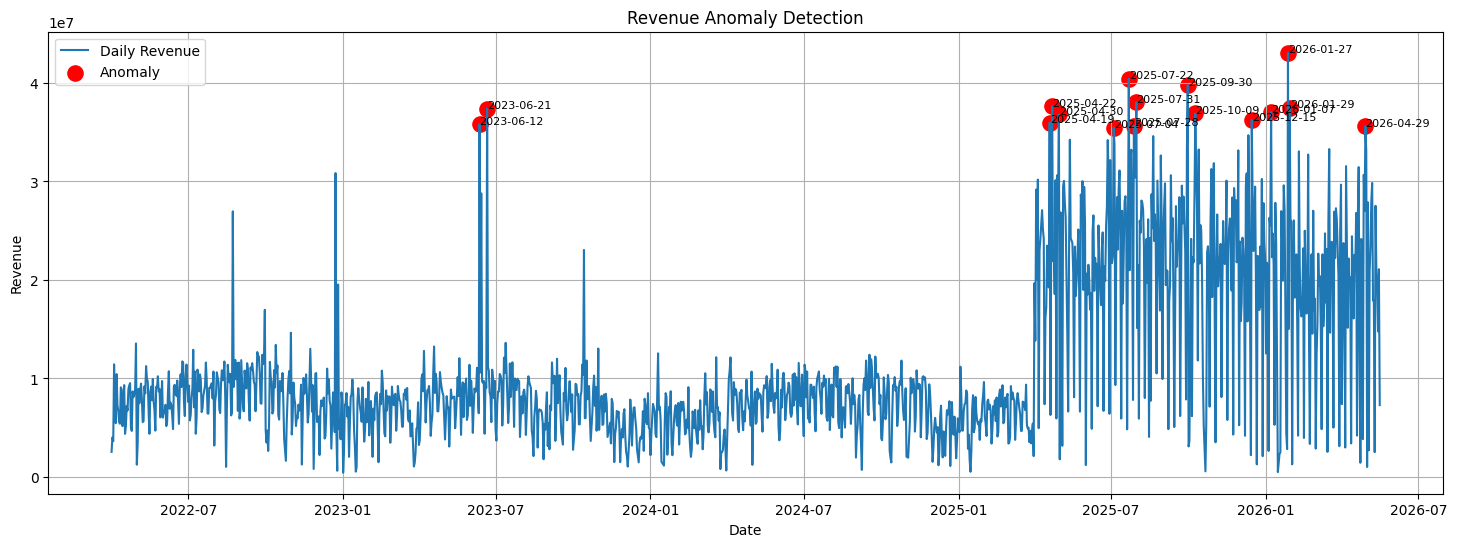

In [178]:
# Plot revenue trend with anomaly highlighted

plt.figure(figsize=(18,6))

# Revenue trend
plt.plot(daily_revenue['Inv Date'],daily_revenue['Revenue'],label='Daily Revenue')

# Highlight anomalies
plt.scatter(anomalies['Inv Date'],anomalies['Revenue'],color='red',s=120,label='Anomaly')

# Annotate anomaly points
for i, row in anomalies.iterrows():
    plt.text(row['Inv Date'],row['Revenue'],row['Inv Date'].strftime('%Y-%m-%d'),fontsize=8)

plt.title('Revenue Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

In [179]:
# Extracting Transactions for Spike day

spike_date = '2026-01-27'

spike_transactions = df[df['Inv Date'] == spike_date]

print(spike_transactions.shape)
spike_transactions

(145, 11)


,Account,Cust Code,Part Code,Inv Date,Quantity,Price,Tax,Others,Revenue,Month,Day_name
217952,Account B,Cust-00094,Part-01139,2026-01-27,8853.0,120.00,0.00,0.00,1062360.00,1,Tuesday
217953,Account B,Cust-00317,Part-00045,2026-01-27,360.0,238.50,0.00,0.00,85860.00,1,Tuesday
217954,Account B,Cust-00442,Part-00149,2026-01-27,120.0,250.88,0.00,0.00,30105.60,1,Tuesday
217955,Account B,Cust-00738,Part-00010,2026-01-27,4080.0,240.00,0.00,0.00,979200.00,1,Tuesday
217956,Account B,Cust-00566,Part-00315,2026-01-27,1200.0,269.00,0.00,0.00,322800.00,1,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...
218092,Account A,Cust-00302,Part-01236,2026-01-27,-1.0,-1745.33,-120.83,-671.34,953.16,1,Tuesday
218093,Account A,Cust-00302,Part-01398,2026-01-27,-1.0,-2960.45,-180.64,-652.37,2127.44,1,Tuesday
218094,Account A,Cust-00302,Part-01295,2026-01-27,-1.0,-2109.30,-137.00,-630.64,1341.66,1,Tuesday
218095,Account A,Cust-00302,Part-01295,2026-01-27,-1.0,-2109.30,-137.00,-630.64,1341.66,1,Tuesday


In [180]:
# Product contribution on Spike day
spike_products = spike_transactions.groupby('Part Code')['Revenue'].sum().sort_values()

spike_products.head()

,Revenue
Part Code,
Part-01505,365.61
Part-01896,772.80
Part-01236,953.16
Part-01284,1040.03
Part-01196,2208.94


In [181]:
# Customer contribution on Spike day
spike_customers = spike_transactions.groupby('Cust Code')['Revenue'].sum().sort_values()

spike_customers.head()

,Revenue
Cust Code,
Cust-00619,28620.00
Cust-00442,30105.60
Cust-00361,37792.00
Cust-00026,38256.75
Cust-00302,46211.37


In [182]:
avg_daily_revenue = (daily_revenue['Revenue'].mean())

spike_revenue = (spike_transactions['Revenue'].sum())

extra_revenue = (spike_revenue-avg_daily_revenue)

print('Average daily revenue:',avg_daily_revenue)
print('Spike revenue:',spike_revenue)
print('Extra revenue:',extra_revenue)

Average daily revenue: 11033170.15740503
Spike revenue: 43059999.118999995
Extra revenue: 32026828.961594965


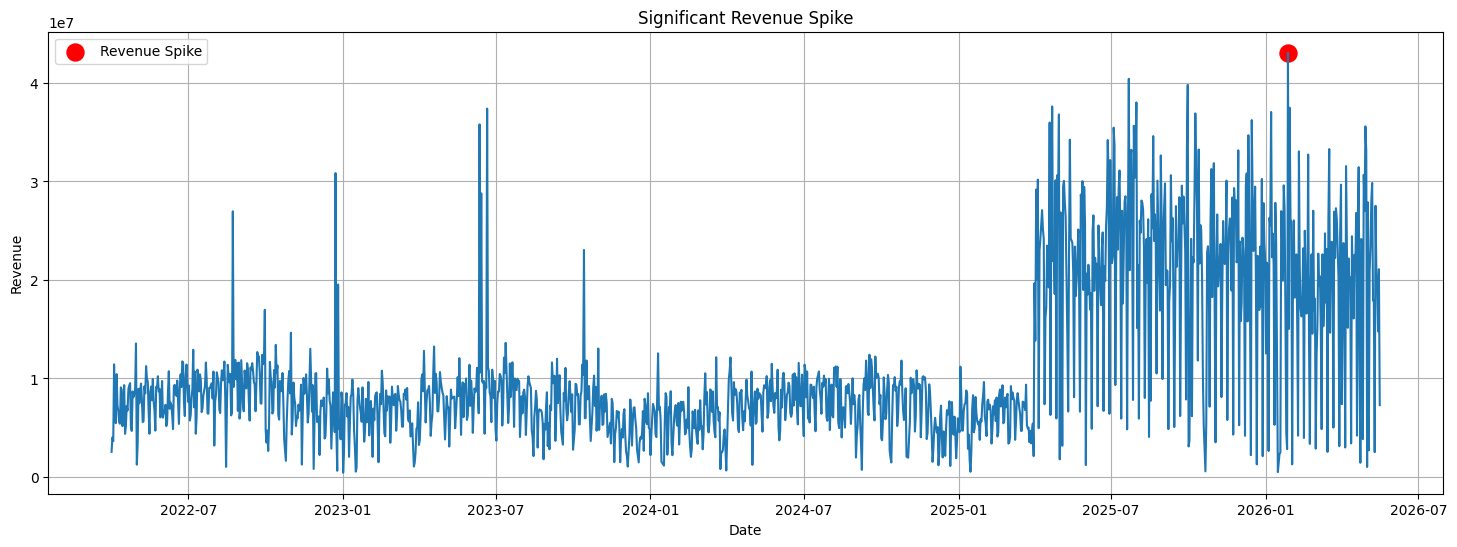

In [183]:
plt.figure(figsize=(18,6))

plt.plot(daily_revenue['Inv Date'],daily_revenue['Revenue'])

plt.scatter(pd.to_datetime(spike_date),spike_revenue,color='red',s=150,label='Revenue Spike')

plt.title('Significant Revenue Spike')

plt.xlabel('Date')
plt.ylabel('Revenue')

plt.legend()

plt.grid(True)

plt.show()

## Root Cause Analysis

A major revenue spike was identified on 2026-01-27, where revenue was much higher than normal business levels.

After analyzing the transactions for that day, it was observed that:
- a few customers generated a very large portion of the revenue
- some high-value products had unusually high sales
- the number of transactions and order quantities were higher than average

This indicates that the spike was likely caused by:
- large customer orders
- bulk product purchases
- increased dispatch activity
- higher demand for certain products

Overall, the spike appears to be the result of concentrated business activity from key customers and products rather than normal day-to-day sales variation.

## What-If Scenario

If this revenue spike had not happened, the daily revenue would probably have stayed close to the normal average revenue level.

The analysis showed that this event generated a large increase in revenue compared to a regular business day.

This highlights how:
- large customer orders
- high-volume sales
- strong demand for certain products

can significantly impact short-term revenue and production planning.

## How PlantNxt Could Predict or Flag This Earlier

PlantNxt’s AI platform could help identify similar revenue spikes in advance by continuously monitoring sales and transaction activity.

The system could:
- track real-time orders and sales trends
- detect sudden increases in customer demand
- identify unusual transaction volumes
- analyze customer purchasing behavior patterns

It could automatically alert the planning team when:
- very large orders are placed
- demand for certain products increases suddenly
- operational capacity may become overloaded

This would help the business:
- manage inventory more effectively
- adjust production schedules in advance
- improve supply-chain planning
- avoid delays or operational bottlenecks